🔴 RISK LAYER 1: ADDRESS-STRING SCREENING

Purpose: Identify hidden sanctioned locations in consignee addresses
Regulatory Basis: OFAC Sanctions, BIS Entity List

📦 Analyzing 5,000 shipments...

📋 Sanctioned Keywords (12 total):
    1. NORTH KOREA
    2. PYONGYANG
    3. IRAN
    4. TEHRAN
    5. SYRIA
    6. DAMASCUS
    7. CRIMEA
    8. SIMFEROPOL
    9. CUBA
   10. HAVANA
   11. VENEZUELA
   12. CARACAS

📊 RESULTS:
   ┌─ Shipments with hidden sanctioned addresses: 101
   ├─ Defect Rate: 2.02%
   └─ Clean shipments: 4,899

🔍 ALL DEFECTIVE SHIPMENTS:


,shipment_id,consignee_name,consignee_address,consignee_country,shipment_date,exporter_business_unit
12,EXP-100012,PEACEFUL MEDICAL SUPPLIES,"KORDAY ROAD, PYONGYANG, NORTH KOREA",NORTH KOREA,2025-10-14,US-ConsumerElectronics
15,EXP-100015,PACIFIC TRADING GROUP,"123 Corporate Blvd, Dublin, IE, PYONGYANG, NOR...",CRIMEA,2025-11-14,US-ConsumerElectronics
27,EXP-100027,AL-KHOBAR DISTRIBUTORS,"234 Innovation Drive, Bangalore, IN, SIMFEROPO...",SYRIA,2026-02-27,US-MedicalDevices
67,EXP-100067,NORTH STAR SUPPLY,"234 Innovation Drive, Bangalore, IN, PYONGYANG...",NORTH KOREA,2026-05-12,US-MedicalDevices
74,EXP-100074,NORTH STAR SUPPLY,"567 Business Park, Singapore, SG, SIMFEROPOL, ...",NORTH KOREA,2026-06-22,US-AerospaceParts
...,...,...,...,...,...,...
4450,EXP-104450,ATLANTIC DISTRIBUTORS,"678 Commerce Street, Mexico City, MX, SIMFEROP...",NORTH KOREA,2025-08-12,US-MedicalDevices
4464,EXP-104464,MED-SUPPLY-EU,"234 Innovation Drive, Bangalore, IN, SIMFEROPO...",SYRIA,2026-03-15,US-AerospaceParts
4483,EXP-104483,PACIFIC TRADING GROUP,"321 Avenue de la Gare, Brussels, BE, PYONGYANG...",NORTH KOREA,2026-05-12,US-MedicalDevices
4514,EXP-104514,PACIFIC TRADING GROUP,"234 Innovation Drive, Bangalore, IN, PYONGYANG...",IRAN,2026-04-09,US-MedicalDevices



🔍 SAMPLE DEFECTS (First 5):

   ┌─ Shipment: EXP-100012
   ├─ Date: 2025-10-14
   ├─ Consignee: PEACEFUL MEDICAL SUPPLIES
   ├─ Address: KORDAY ROAD, PYONGYANG, NORTH KOREA...
   ├─ Country: NORTH KOREA
   └─ Business Unit: US-ConsumerElectronics

   ┌─ Shipment: EXP-100015
   ├─ Date: 2025-11-14
   ├─ Consignee: PACIFIC TRADING GROUP
   ├─ Address: 123 Corporate Blvd, Dublin, IE, PYONGYANG, NORTH KOREA...
   ├─ Country: CRIMEA
   └─ Business Unit: US-ConsumerElectronics

   ┌─ Shipment: EXP-100027
   ├─ Date: 2026-02-27
   ├─ Consignee: AL-KHOBAR DISTRIBUTORS
   ├─ Address: 234 Innovation Drive, Bangalore, IN, SIMFEROPOL, CRIMEA...
   ├─ Country: SYRIA
   └─ Business Unit: US-MedicalDevices

   ┌─ Shipment: EXP-100067
   ├─ Date: 2026-05-12
   ├─ Consignee: NORTH STAR SUPPLY
   ├─ Address: 234 Innovation Drive, Bangalore, IN, PYONGYANG, NORTH KOREA...
   ├─ Country: NORTH KOREA
   └─ Business Unit: US-MedicalDevices

   ┌─ Shipment: EXP-100074
   ├─ Date: 2026-06-22
   ├─ Consignee: 

,Business Unit,Total Shipments,Address Red Flags,Defect Rate %
1,US-ConsumerElectronics,1582,43,2.72
2,US-IndustrialEquipment,966,19,1.97
4,US-Pharmaceuticals,478,9,1.88
3,US-MedicalDevices,1239,21,1.69
0,US-AerospaceParts,735,9,1.22



⚠️ HIGHEST RISK BUSINESS UNIT: US-ConsumerElectronics
   Defect Rate: 2.72%
   Total Address Red Flags: 43

📅 MONTHLY DEFECT RATE:


,sum,count,defect_rate
shipment_month,,,
2025-07,8,349,2.29
2025-08,10,415,2.41
2025-09,5,401,1.25
2025-10,12,433,2.77
2025-11,10,430,2.33
2025-12,8,465,1.72
2026-01,7,384,1.82
2026-02,3,395,0.76
2026-03,5,402,1.24



📈 TREND (Last 6 months):
   2026-02:  0.76% 
   2026-03:  1.24% 
   2026-04:  3.00% █
   2026-05:  2.71% █
   2026-06:  1.02% 
   2026-07:  5.38% ██


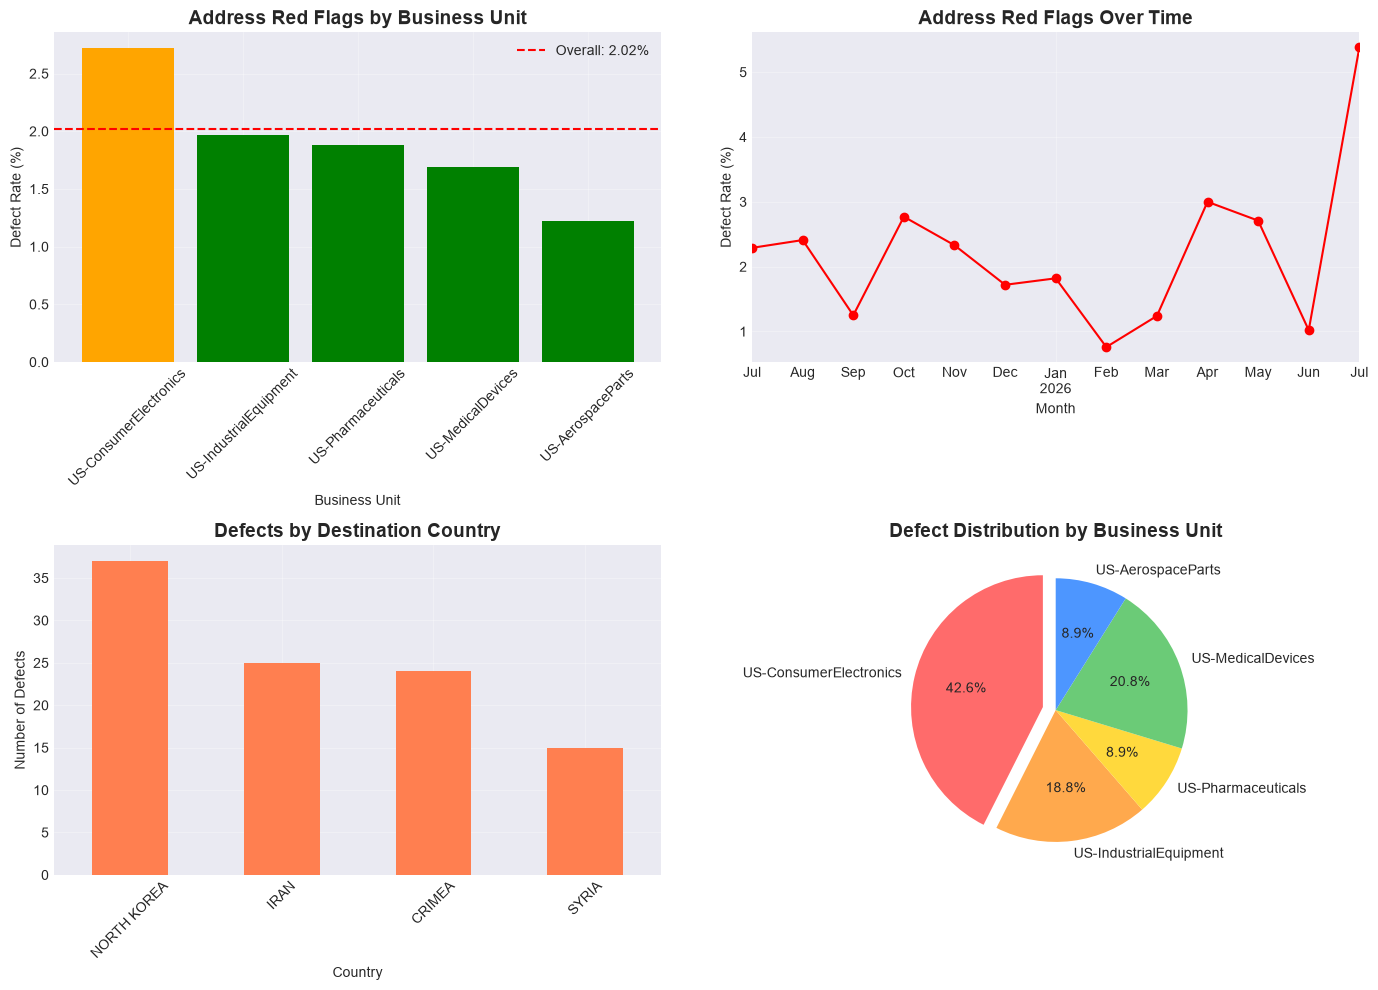


💾 Saved: output/risk_layer1_address_screening.png

💾 Saved: us_export_compliance_data_layer1.csv

✅ RISK LAYER 1 COMPLETE!


In [4]:
# %% [markdown]
# # 🔴 Risk Layer 1: Address-String Screening
# 
# **Purpose**: Identify hidden sanctioned locations in consignee addresses
# 
# **Regulatory Basis**: OFAC Sanctions, BIS Entity List
# 
# **Key Question**: Are we inadvertently shipping to sanctioned entities?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔴 RISK LAYER 1: ADDRESS-STRING SCREENING")
print("="*70)
print("\nPurpose: Identify hidden sanctioned locations in consignee addresses")
print("Regulatory Basis: OFAC Sanctions, BIS Entity List")

# %% [code]
# Load dataset with dates
df = pd.read_csv('us_export_compliance_data.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments...")

# %% [markdown]
# ## Define Sanctioned Keywords
# 
# Based on OFAC's Specially Designated Nationals (SDN) list and BIS Entity List

# %% [code]
# Define sanctioned keywords
SANCTIONED_KEYWORDS = [
    'NORTH KOREA', 'PYONGYANG',  # North Korea
    'IRAN', 'TEHRAN',             # Iran
    'SYRIA', 'DAMASCUS',          # Syria
    'CRIMEA', 'SIMFEROPOL',       # Crimea
    'CUBA', 'HAVANA',             # Cuba
    'VENEZUELA', 'CARACAS'        # Venezuela
]

print(f"\n📋 Sanctioned Keywords ({len(SANCTIONED_KEYWORDS)} total):")
for i, keyword in enumerate(SANCTIONED_KEYWORDS, 1):
    print(f"   {i:2d}. {keyword}")

# %% [markdown]
# ## Apply Screening Logic

# %% [code]
# Create the red flag column (case-insensitive)
df['address_red_flag'] = df['consignee_address'].str.upper().apply(
    lambda x: any(kw in x for kw in [kw.upper() for kw in SANCTIONED_KEYWORDS])
)

# Count matches
address_risk_count = df['address_red_flag'].sum()
address_risk_rate = (address_risk_count / len(df)) * 100

print(f"\n📊 RESULTS:")
print(f"   ┌─ Shipments with hidden sanctioned addresses: {address_risk_count:,}")
print(f"   ├─ Defect Rate: {address_risk_rate:.2f}%")
print(f"   └─ Clean shipments: {len(df) - address_risk_count:,}")

# %% [markdown]
# ## Examine the Defects Found

# %% [code]
# Show all defective shipments
if address_risk_count > 0:
    print("\n🔍 ALL DEFECTIVE SHIPMENTS:")
    defects_df = df[df['address_red_flag']][
        ['shipment_id', 'consignee_name', 'consignee_address', 
         'consignee_country', 'shipment_date', 'exporter_business_unit']
    ]
    display(defects_df)
    
    # Show first 5 examples
    print("\n🔍 SAMPLE DEFECTS (First 5):")
    sample_defects = defects_df.head(5)
    for idx, row in sample_defects.iterrows():
        print(f"\n   ┌─ Shipment: {row['shipment_id']}")
        print(f"   ├─ Date: {row['shipment_date'].strftime('%Y-%m-%d')}")
        print(f"   ├─ Consignee: {row['consignee_name']}")
        print(f"   ├─ Address: {row['consignee_address'][:80]}...")
        print(f"   ├─ Country: {row['consignee_country']}")
        print(f"   └─ Business Unit: {row['exporter_business_unit']}")

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
bu_analysis = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'address_red_flag': 'sum'
}).reset_index()

bu_analysis.columns = ['Business Unit', 'Total Shipments', 'Address Red Flags']
bu_analysis['Defect Rate %'] = (bu_analysis['Address Red Flags'] / bu_analysis['Total Shipments'] * 100).round(2)
bu_analysis = bu_analysis.sort_values('Defect Rate %', ascending=False)

print("\n📊 ANALYSIS BY BUSINESS UNIT:")
display(bu_analysis)

# Identify worst performer
worst_unit = bu_analysis.iloc[0]['Business Unit']
worst_rate = bu_analysis.iloc[0]['Defect Rate %']
worst_count = bu_analysis.iloc[0]['Address Red Flags']

print(f"\n⚠️ HIGHEST RISK BUSINESS UNIT: {worst_unit}")
print(f"   Defect Rate: {worst_rate:.2f}%")
print(f"   Total Address Red Flags: {worst_count}")

# %% [markdown]
# ## Time-Based Analysis

# %% [code]
# Monthly defect rate
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_defects = df.groupby('shipment_month')['address_red_flag'].agg(['sum', 'count'])
monthly_defects['defect_rate'] = (monthly_defects['sum'] / monthly_defects['count'] * 100).round(2)

print("\n📅 MONTHLY DEFECT RATE:")
display(monthly_defects)

# Show trend
print("\n📈 TREND (Last 6 months):")
for month, row in monthly_defects.tail(6).iterrows():
    rate = row['defect_rate']
    bar = '█' * int(rate / 2)
    print(f"   {month}: {rate:5.2f}% {bar}")

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Defects by Business Unit
colors = ['red' if rate > 5 else 'orange' if rate > 2 else 'green' 
          for rate in bu_analysis['Defect Rate %']]
axes[0,0].bar(bu_analysis['Business Unit'], bu_analysis['Defect Rate %'], color=colors)
axes[0,0].set_title('Address Red Flags by Business Unit', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Business Unit')
axes[0,0].set_ylabel('Defect Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=address_risk_rate, color='red', linestyle='--', 
                  label=f'Overall: {address_risk_rate:.2f}%')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Time series trend
monthly_defects['defect_rate'].plot(kind='line', ax=axes[0,1], marker='o', color='red')
axes[0,1].set_title('Address Red Flags Over Time', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Defect Rate (%)')
axes[0,1].grid(True, alpha=0.3)

# 3. Defect count by country
country_defects = df[df['address_red_flag']]['consignee_country'].value_counts()
if len(country_defects) > 0:
    country_defects.plot(kind='bar', ax=axes[1,0], color='coral')
    axes[1,0].set_title('Defects by Destination Country', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Country')
    axes[1,0].set_ylabel('Number of Defects')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3)

# 4. Pie chart - defect distribution by business unit
colors_pie = ['#ff6b6b', '#ffa94d', '#ffd93d', '#6bcb77', '#4d96ff']
bu_defects = bu_analysis[bu_analysis['Address Red Flags'] > 0]
if len(bu_defects) > 0:
    explode = [0.1 if i == 0 else 0 for i in range(len(bu_defects))]
    axes[1,1].pie(bu_defects['Address Red Flags'], 
                  labels=bu_defects['Business Unit'],
                  autopct='%1.1f%%',
                  colors=colors_pie[:len(bu_defects)],
                  explode=explode,
                  startangle=90)
    axes[1,1].set_title('Defect Distribution by Business Unit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/risk_layer1_address_screening.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/risk_layer1_address_screening.png")

# %% [code]
# Save the enhanced dataset with this risk layer
df.to_csv('us_export_compliance_data_layer1.csv', index=False)
print("\n💾 Saved: us_export_compliance_data_layer1.csv")

print("\n" + "="*70)
print("✅ RISK LAYER 1 COMPLETE!")
print("="*70)